In [3]:
import pickle

pkl_file_path = "/home/uynk/Belgeler/Analyze_Projects/AliBaba_GenAI_Dataset/dataframes.pkl"

with open(pkl_file_path, 'rb') as file:
    dataframes = pickle.load(file)

# EDA
### **<span style="color:orange">Request Types, Bar & Scatter Plot</span>**

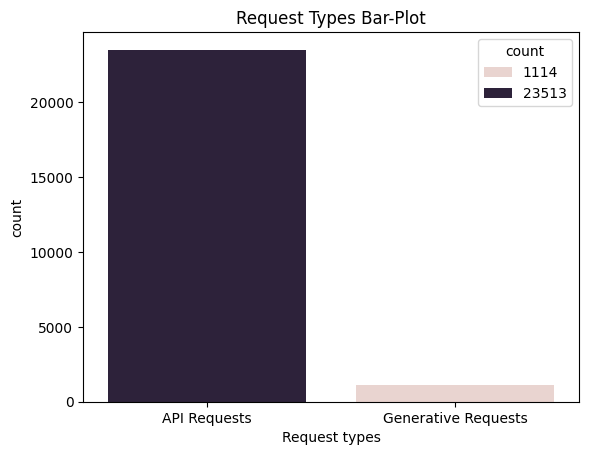

Number of active pod types within the (Timestamp('2022-09-11 01:19:36'), Timestamp('2022-09-11 23:38:09')) time range: 107


<Figure size 640x480 with 0 Axes>

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.barplot(dataframes, x=dataframes["qps.csv"]["request_type"].unique(), y=dataframes["qps.csv"]["request_type"].value_counts(),
            hue=dataframes["qps.csv"]["request_type"].value_counts())
plt.title("Request Types Bar-Plot")
plt.xlabel("Request types")
plt.ylabel("count")
plt.show()


print(f"Number of active pod types within the {(dataframes['qps.csv']['real_time'].min(), dataframes['qps.csv']['real_time'].max())} time range: {dataframes['qps.csv']['container_ip'].nunique()}")
plt.savefig("API_GEN_req_barplot")

**The reasons why API req is higher than Gen req could be the following:**
1. End-Users: A single GenAI generation by a user (GenReq) causes the browser or application to fire dozens of API requests to the system in the background. The user sends the prompt. As the model generates the output word by word (token by token), the system constantly performs status checks (polling) or sends data packets in the background to instantly reflect that streaming text on the user's screen. So, the user thinks, "I just pressed one generate button," but meanwhile, the system is working like a bee in the background, generating 20-30 API requests.
2. Developers' applications (for example, a mobile game studio's character generation bot) can send thousands of consecutive and concurrent requests to the system. Due to authentication (API Key) and quota checks, this is the group that turns the API Gateway into a revolving door the most.
3. Prometheus, metric-server, or AliBaba's CloudMonitor systems call Infrastructure APIs every 5-10 seconds to check the health status and memory usage of pods and GPUs. Even if there are no live users on the system, that "never-zeroing baseline API load" you see in the charts comes from the automations set up by these engineers.
4. Because they work via Jupyter Notebook or PAI (Platform for AI) tools, they do not click as much as a standard web user. However, when uploading or calling large model files to storage areas (NAS, OSS), they heavily occupy the File and Management APIs.
5. These are all the raw requests sent to the system by users. This number includes all the "pre-requests" that failed authentication (Auth), exceeded their quota, sent incorrect parameters, or were eliminated by timing out because queue times in the system became too long.
6. Not every incoming API request makes it to that heavy stage where the model runs. These API requests might not necessarily stress the GPU. They could just fetch information from the file list over the Persistent Volume, perform a LoRA catalog query (e.g., checking which Anime or cyberpunk styles are available to use), etc.
7. If identical requests come from multiple users, the system might have batched them together and sent them to the GPU as a single request.

### **<span style="color:orange"> Line Plot of Incoming Requests by Time</span>**

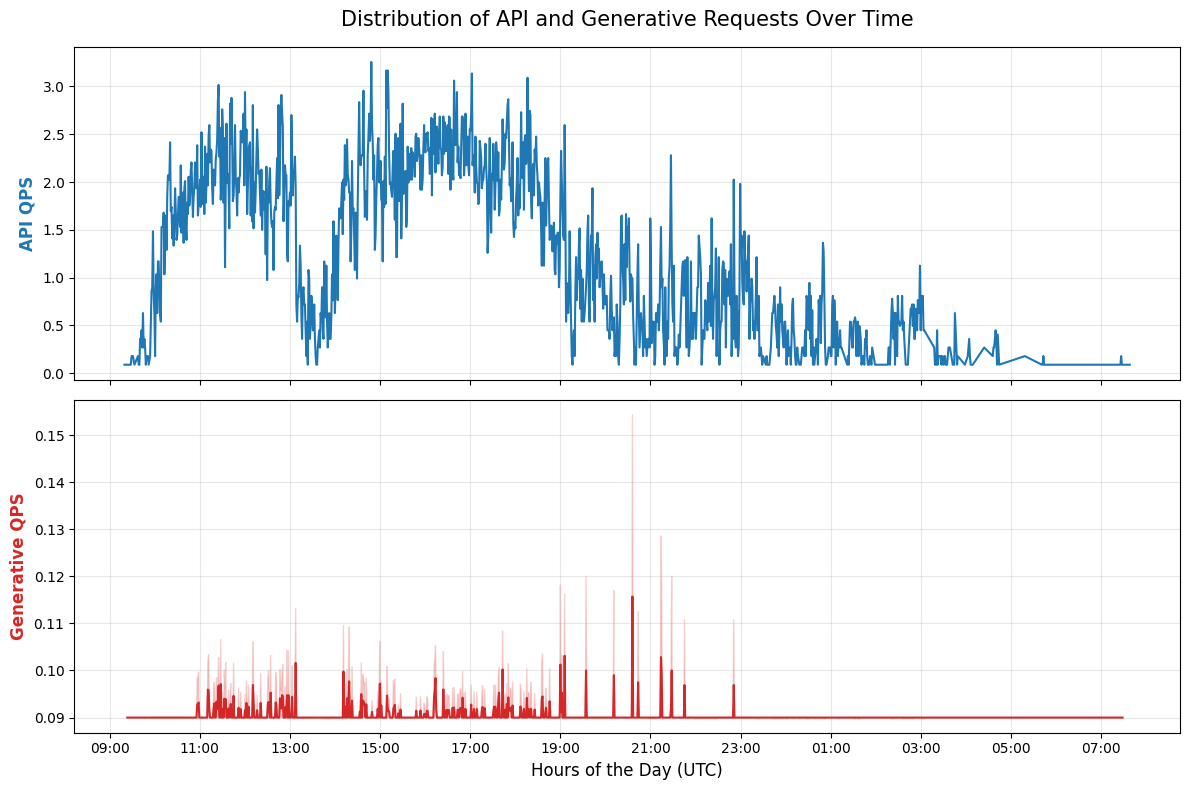

,timestamp_anon,value,container_ip,request_type,real_time,real_time_CST
0,1.662859e+09,0.09,NaN,API Requests,2022-09-11 01:19:36,2022-09-11 09:19:36
1,1.662859e+09,0.09,NaN,API Requests,2022-09-11 01:20:33,2022-09-11 09:20:33
2,1.662859e+09,0.09,dfe00e981377fa8e0a9aefbc9b2e9369,Generative Requests,2022-09-11 01:23:24,2022-09-11 09:23:24
3,1.662859e+09,0.09,cbfb6b40cb1caa54ab6de789bb801645,Generative Requests,2022-09-11 01:24:21,2022-09-11 09:24:21
4,1.662859e+09,0.09,NaN,API Requests,2022-09-11 01:24:21,2022-09-11 09:24:21


<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df1 = dataframes["qps.csv"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=df1[df1["request_type"] == "API Requests"], 
             x="real_time_CST", y="value", ax=ax1, color="tab:blue")
ax1.set_ylabel("API QPS", fontsize=12, fontweight="bold", color="tab:blue")
ax1.set_title("Distribution of API and Generative Requests Over Time", fontsize=15, pad=15)
ax1.grid(True, alpha=0.3)

sns.lineplot(data=df1[df1["request_type"] == "Generative Requests"], 
             x="real_time_CST", y="value", ax=ax2, color="tab:red")
ax2.set_ylabel("Generative QPS", fontsize=12, fontweight="bold", color="tab:red")
ax2.set_xlabel("Hours of the Day (UTC)", fontsize=12)
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2)) 

plt.tight_layout()
plt.show()
plt.savefig('API_GEN_req_distrubution.png')

display(df1.head())

`Graph interpretation:` It is observed that the main load coming into the system (image generation) is intermittent, but these intermittent events are immediately followed by a massive barrage of API (blue) queries. A decrease is observed between 13:00 and 14:00 on weekdays; the reason for this might be that these are outside of regular working hours (e.g., lunch break). Based on this deduction, it can be assumed that the majority of the Cloud system users for that day consisted of End-users, Enterprise, or Interactive users.